#Semi Supervised Node Classification on citation networks using Graph Convolutional Networks (GCN)

Objective : A graph with few nodes are labeled and rest of the nodes are unlabeled. We need to find rest of the node labels utilizing the available node features and information about graph structure *(like adjacency matrix)*


Real World Scenario : The citation networks are typically undirected, unweighted graphs, where nodes denote academic publications and edge represents the citations between two papers. Every node belongs to one of the academic subjects. Under Semi-Supervised settings, few labeled nodes are available for training. Our target is to classify rest of the nodes by exploiting the graph structure.

*Installing the required packages*

In [ ]:
import numpy as np
import os
import torch
os.environ['TORCH']=torch.__version__
print(torch.__version__)

import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com//pyg-team/pytorch_geometric.git

import torch_geometric.nn as gnn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import torch_geometric.utils

import networkx as nx


2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Load Citation Datasets like 'Cora' or 'Citeseer' or 'Pubmed'

In [ ]:
dataset = Planetoid(root='data/planetoid', name='Cora', transform=NormalizeFeatures())


Processing...
Done!


In [ ]:
type(dataset)

torch_geometric.datasets.planetoid.Planetoid

In [ ]:
dataset

Cora()

In [ ]:
data =  dataset[0] #selecting data from the list of datasets, in this case only one graph is available
print(data)
type(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


torch_geometric.data.data.Data

x = [2708,1433] :: 2708 - nodes and 1433 - feature dimension

In [ ]:
data.edge_index

tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])

In [ ]:
#The following properties are shared with all graphs containing the dataset (here it is 1)

print('Number of graphs \t',len(dataset))
print('Number of features \t',dataset.num_features)
print('Number of classes \t',dataset.num_classes)

Number of graphs 	 1
Number of features 	 1433
Number of classes 	 7


In [ ]:
# The following properties are graph specific and it varies across the different graphs

print('Number of nodes \t',data.num_nodes)
print('Number of edges \t',data.num_edges)

print("Train mask visulization :",data.train_mask,data.train_mask.shape)
print("No. of Training node : ", data.train_mask.sum().item())

print("Validation mask visulization :",data.val_mask,data.val_mask.shape)
print("No. of Validation node : ", data.val_mask.sum().item())

print("Test mask visulization :",data.test_mask,data.test_mask.shape)
print("No. of Test node : ",data.test_mask.sum().item())

print("Does the graph contain isolated nodes :",data.has_isolated_nodes())
print("Does the graph contain self loops :",data.has_self_loops())
print("Is the graph undirected :",data.is_undirected())

Number of nodes 	 2708
Number of edges 	 10556
Train mask visulization : tensor([ True,  True,  True,  ..., False, False, False]) torch.Size([2708])
No. of Training node :  140
Validation mask visulization : tensor([False, False, False,  ..., False, False, False]) torch.Size([2708])
No. of Validation node :  500
Test mask visulization : tensor([False, False, False,  ...,  True,  True,  True]) torch.Size([2708])
No. of Test node :  1000
Does the graph contain isolated nodes : False
Does the graph contain self loops : False
Is the graph undirected : True


In [ ]:
#feature matrix x

print("features of the graph \t",data.x)
print("Shape of X \t",data.x.shape)


features of the graph 	 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
Shape of X 	 torch.Size([2708, 1433])


In [ ]:
#class labels
print("labels of the node \t", data.y)
print("Shape :",data.y.shape)

labels of the node 	 tensor([3, 4, 4,  ..., 3, 3, 3])
Shape : torch.Size([2708])


In [ ]:
#structural Information
print("List of edges in the graph \t",data.edge_index)
print("Shape of edge_index \t",data.edge_index.shape)

print("Source nodes \t", data.edge_index[0])
print("Target nodes \t", data.edge_index[1])

List of edges in the graph 	 tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])
Shape of edge_index 	 torch.Size([2, 10556])
Source nodes 	 tensor([ 633, 1862, 2582,  ...,  598, 1473, 2706])
Target nodes 	 tensor([   0,    0,    0,  ..., 2707, 2707, 2707])


In [ ]:
data.x[0][: 100]  #first 100 features of a node

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.1111, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.1111, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])

In [ ]:
#Visualizing the node embeddings

def Visualize(h,color):
  z= TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())
  plt.figure(figsize=(10,10))
  plt.xticks([])
  plt.yticks([])
  plt.scatter(z[:,0],z[:,1],s=70,c=color,cmap="Set2")
  plt.show()


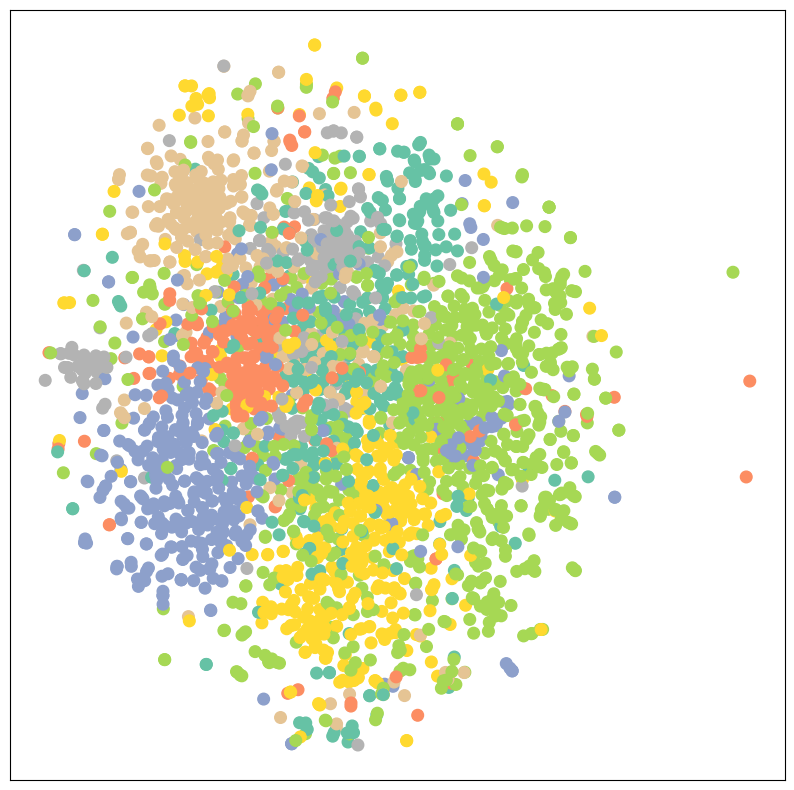

In [ ]:
Visualize(data.x,data.y)

**Graph  Laplacian**

If D and A are the degree matrix and adjacency matrix respectively

1. Unnormalize Laplacian  is $L = D - A$
2. Random Walk Laplacian is $L_{rw}=D^{-1}L$
3. Symmetrically Normalized graph Laplacian is $L_{sym}=D^{-1/2}LD^{1/2}$

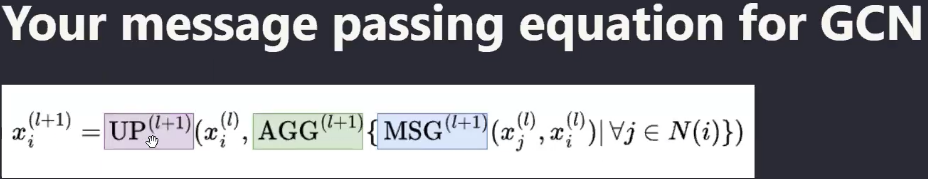

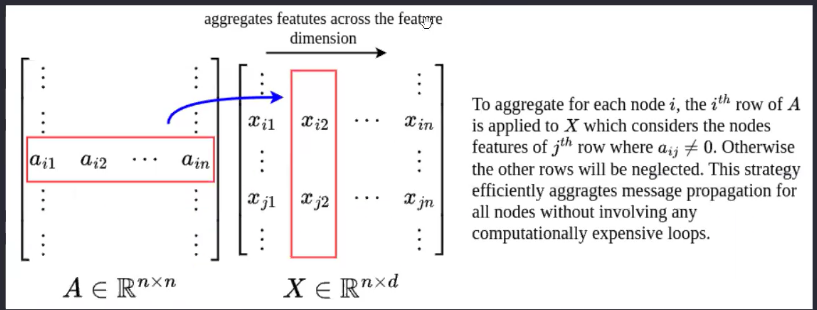

#Message Propagation rule of GCN

Let A be the adjacency matrix and X is the feature matrix then

$$X^{(l+1)} = \sigma(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} X^{(l)} W^{(l)})$$

where $$\tilde{A}= A + I$$ and $$\tilde{D}= D + I$$

$X^l$ denotes feature matrix at $l^{th}$ layer

$W^l$ is the trainable weight matrix at layer l

$\sigma$ is the non linear activation function

*Self loops are added to consider own features as neighbors. This leads to more effective message propagation*

In [ ]:
import math
import torch

from torch.nn.parameter import Parameter
from torch.nn.modules.module import Module

In [ ]:
#define Single graph convolutional layer

class GraphCN(Module):
  def __init__(self, in_features, out_features, bias=True):
    super(GraphCN,self).__init__()
    self.in_features=in_features
    self.out_features=out_features

    self.weight=Parameter(torch.FloatTensor(in_features,out_features))
    if bias:
      self.bias=Parameter(torch.FloatTensor(out_features))
    self.reset_parameter()

  def reset_parameter(self):
    stdv = 1. / math.sqrt(self.weight.size(1))
    self.weight.data.uniform_(-stdv,stdv)

    if self.bias is not None:
      self.bias.data.uniform_(-stdv,stdv)

  def forward(self,input,adj):
    support = torch.mm(input, self.weight)
    output = torch.mm(adj,support)
    if self.bias is not None:
      return output + self.bias
    else :
      return output



### Message propagation in a two-layered GCN

$$Z = \text{softmax}(\hat{A} \cdot \text{ReLU}(\hat{A} X W^{(0)}) W^{(1)})$$

where $W^{(0)}, W^{(1)}$ are two trainable weight matrices,

* $Z \in \mathbb{R}^{n \times c}$ is the node embeddings at the final layer where $c$ is the number of classes
* $X \in \mathbb{R}^{n \times d}$ is the input feature matrix.
* $\hat{A} = \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}}$

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class GCN(nn.Module):
  def __init__(self,nfeat,nhid,nclass,dropout):
    super(GCN,self).__init__()

    self.gc1 = GraphCN(nfeat,nhid)
    self.gc2 = GraphCN(nhid,nclass)
    self.dropout = dropout

  def forward(self,x,adj):
      #first layer
      x=self.gc1(x,adj)
      x=F.relu(x)
      x=F.dropout(x,self.dropout,training=self.training)

      #second layer
      x=self.gc2(x,adj)
      return x

Symmetrically Normalise Adjacency matrix

In [ ]:
def norm_adj(edge_index):
  adj_matrix = torch.zeros(data.num_nodes,data.num_nodes)

  for e in range(data.num_edges):
    src = data.edge_index[0][e]
    tgt = data.edge_index[1][e]
    adj_matrix[src][tgt]=1

  adj_matrix += torch.eye(data.num_nodes)
  degrees = torch.sum(adj_matrix,dim=1)
  degree_matrix= torch.diag(1/torch.sqrt(degrees))
  norm_adj = torch.mm(degree_matrix,adj_matrix)
  norm_adj = torch.mm(norm_adj,degree_matrix)

  return norm_adj

If we plug the Identity matrix into the GCN formula, look at what happens:

$$H^{(l+1)} = \sigma(I \times H^{(l)} W^{(l)})$$

Since multiplying any matrix by the Identity matrix just returns the original matrix ($I \times H = H$), the equation simplifies to:

$$H^{(l+1)} = \sigma(H^{(l)} W^{(l)})$$


This is the exact mathematical definition of a standard feed forward linear layer in an MLP.



The "neighborhood aggregation" step completely disappears.

In [ ]:
adj = norm_adj(data.edge_index)

In [ ]:
#before training

model = GCN(dataset.num_features, 16, dataset.num_classes, 0.60)

out = model(data.x,adj)

Visualize(out,color=data.y)

/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


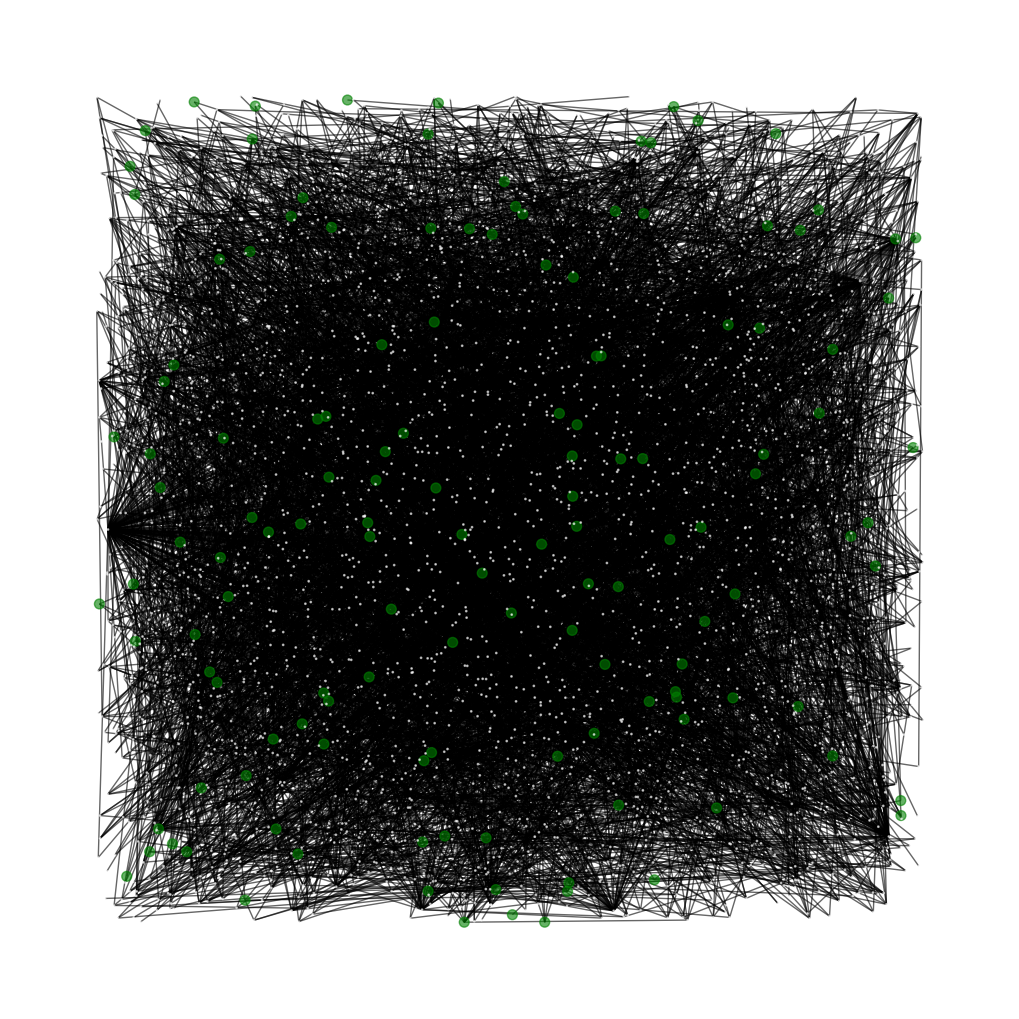

In [ ]:
G = nx.Graph()

G.add_nodes_from(range(data.num_nodes))

color_map = []
node_size = []

for n in range(data.num_nodes):
    if data.train_mask[n]:
        color_map.append('green')
        node_size.append(50)
    else:
        color_map.append('white')
        node_size.append(1)

edge_list = data.edge_index.t().tolist()
G.add_edges_from(edge_list)

plt.figure(figsize=(10, 10))


#pos = nx.spring_layout(G, k=0.15, iterations=20)
#nx.draw(G, pos, node_size=node_size, node_color=color_map, alpha=0.5)

nx.draw_random(
    G,
    with_labels=False,
    node_size=node_size,
    node_color=color_map,
    cmap=plt.cm.Set2, # Use Set2 to turn those class integers into colors
    alpha=0.6
)
plt.show()

In [ ]:
from torch_geometric.utils import homophily
print(f"Homophily: {homophily(data.edge_index, data.y):.4f}")

Homophily: 0.8100


**Transductive settings**

Learning process:

1.The GNN learns from the features of both labeled and unlabeled node, however loss will be solely computed on the basis of training nodes

2.It uses the graph structure to propagte information between the labelled and unlabeled nodes

3.The model leverages the assumption that connected nodes are likely to share similar properties (homophily principle)

In [ ]:
model = GCN(dataset.num_features,32,dataset.num_classes,0.5)
num_epochs=100

optimizer = torch.optim.Adam(model.parameters(),lr=0.01,weight_decay=5e-4)
criterion=torch.nn.CrossEntropyLoss()

train_loss=[]

def train():
  model.train()
  optimizer.zero_grad()
  out=model(data.x,adj)
  loss=criterion(out[data.train_mask],data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  return loss

def test():
  model.eval()
  out=model(data.x,adj)
  pred=out.argmax(dim=1)
  test_correct=pred[data.test_mask] == data.y[data.test_mask]
  test_acc = int(test_correct.sum())/int(data.test_mask.sum())
  return test_acc


In [ ]:
for epoch in range(num_epochs):
  loss=train()
  test_acc=test()
  train_loss.append(loss.item())
  print(f'Epoch : {epoch:03d},Loss : {loss:.4f}, Test Accuracy : {test_acc : .4f}')

Epoch : 000,Loss : 1.9765, Test Accuracy :  0.1030
Epoch : 001,Loss : 1.9583, Test Accuracy :  0.1040
Epoch : 002,Loss : 1.9427, Test Accuracy :  0.1050
Epoch : 003,Loss : 1.9357, Test Accuracy :  0.1050
Epoch : 004,Loss : 1.9195, Test Accuracy :  0.1060
Epoch : 005,Loss : 1.9200, Test Accuracy :  0.1090
Epoch : 006,Loss : 1.9173, Test Accuracy :  0.1150
Epoch : 007,Loss : 1.9195, Test Accuracy :  0.1170
Epoch : 008,Loss : 1.8832, Test Accuracy :  0.1220
Epoch : 009,Loss : 1.8661, Test Accuracy :  0.1470
Epoch : 010,Loss : 1.8590, Test Accuracy :  0.1990
Epoch : 011,Loss : 1.8458, Test Accuracy :  0.2480
Epoch : 012,Loss : 1.8266, Test Accuracy :  0.3050
Epoch : 013,Loss : 1.8195, Test Accuracy :  0.3360
Epoch : 014,Loss : 1.7975, Test Accuracy :  0.3720
Epoch : 015,Loss : 1.7690, Test Accuracy :  0.3960
Epoch : 016,Loss : 1.7472, Test Accuracy :  0.4120
Epoch : 017,Loss : 1.7296, Test Accuracy :  0.4230
Epoch : 018,Loss : 1.6831, Test Accuracy :  0.4360
Epoch : 019,Loss : 1.6958, Test

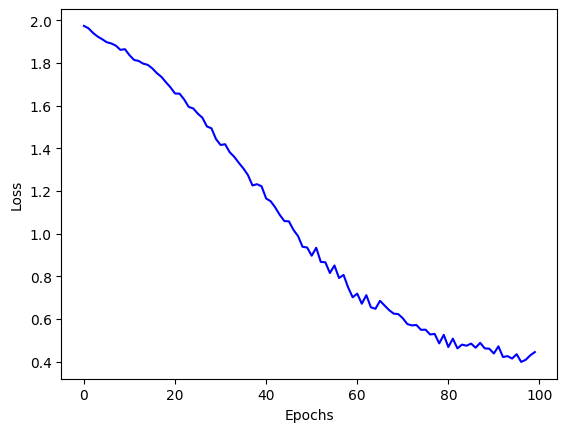

In [ ]:
plt.plot(np.arange(num_epochs),train_loss,color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
model.eval()

test_acc=test()
print(f'Test Accuracy : {test_acc : .4f}')

Test Accuracy :  0.8150


torch.Size([2708, 7])


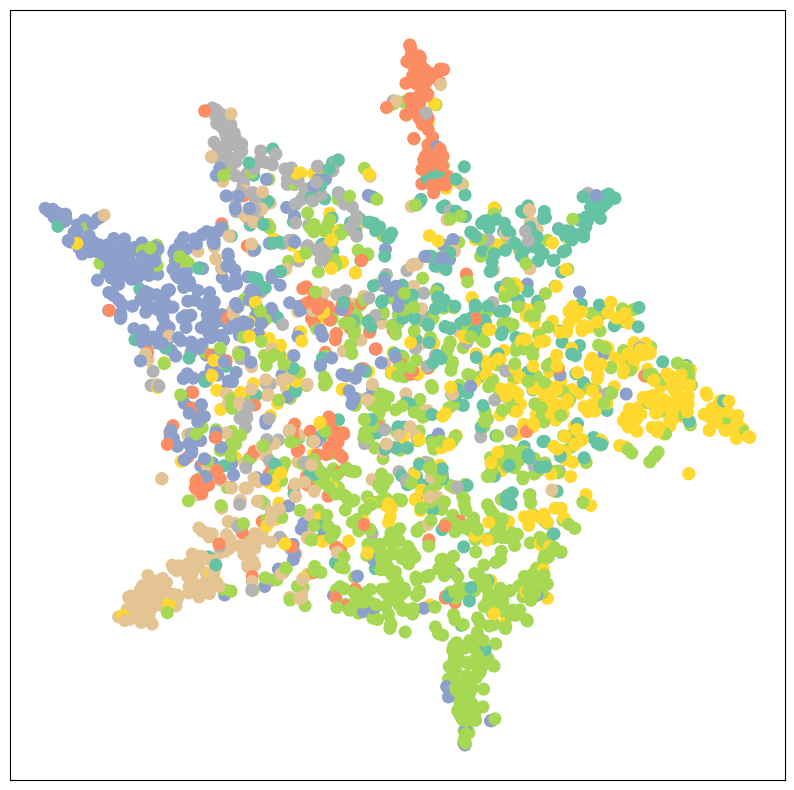

In [ ]:
model.eval()

out=model(data.x,adj)
print(out.shape)

Visualize(out,color=data.y)